In [1]:
import torch
import torch.nn as nn
import numpy as np
import sys
import os
import json
import itertools
import pandas as pd
import gc  # Added for memory cleanup
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# Referencing your project structure verbatim
sys.path.append(os.path.abspath(".."))
from src.architectures import GeneralMLP # Verbatim reference to architectures.py
from src.utils import set_seed, apply_heavy_tailed_init # Verbatim reference to utils.py

def save_physics_snapshot(model, input_batch, output_dir, t_idx, epoch, alpha, g):
    model.eval()

    # Capture physics data as before
    pre_acts = model.get_pre_activations(input_batch)
    linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]

    layer_physics = {}
    for idx, layer in enumerate(linear_layers):
        layer_key = f"layer_{idx}" if idx < len(linear_layers) - 1 else "classifier"
        h = pre_acts[idx] if idx < len(linear_layers) - 1 else pre_acts["classifier"]

        # Compute Jacobian using float32 for precision
        W = layer.weight.data.float()
        d_act = 1.0 - torch.tanh(h).pow(2).float()
        D_avg = d_act.mean(dim=0)
        J = D_avg.unsqueeze(1) * W

        layer_physics[layer_key] = {
            "pre_activations": h.float().cpu(),
            "jacobian": J.cpu()
        }

    snapshot = {
        "metadata": {"task": t_idx + 1, "epoch": epoch, "alpha": alpha, "g": g},
        "state_dict": model.state_dict(), # Native PyTorch format
        "physics": layer_physics         # Your specific research metrics
    }

    output_dir.mkdir(parents=True, exist_ok=True)
    file_path = output_dir / f"snapshot_T{t_idx+1}_E{epoch}.pt"
    torch.save(snapshot, file_path)
    return file_path

In [62]:
# --- 1. CONFIGURATION ---
num_tasks = 10
seed = 42
alpha_list = [2.0, 1.2]
g_list = [0.25, 1.0, 3.0]
depth = 9
hidden_size = 784
bias = False
activation_name = "tanh"
optimiser = "adam"
batch_size = 128
lr = 1e-3
epochs = 30
snapshot_epochs = [0, 14, 29] # Capture snapshots at the start, middle, and end of training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. OPTIMIZED DATA LOADING ---
def get_gpu_data(dataset):
    """Loads raw tensors to GPU once to avoid repetitive overhead[cite: 7]."""
    imgs = torch.stack([img for img, _ in dataset]).to(device).view(-1, 784)
    lbls = torch.tensor([lbl for _, lbl in dataset]).to(device)
    return imgs, lbls

print("Fast-loading MNIST to GPU...")
mnist_train = datasets.MNIST('../data', train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST('../data', train=False, download=True, transform=transforms.ToTensor())

train_imgs, train_lbls = get_gpu_data(mnist_train)
test_imgs_raw, test_lbls = get_gpu_data(mnist_test)

def generate_permutations(num_tasks, num_pixels=784, seed=42):
    rng = np.random.RandomState(seed)
    perms = [torch.arange(num_pixels)]
    for _ in range(num_tasks - 1):
        perms.append(torch.from_numpy(rng.permutation(num_pixels)))
    return perms

permutations = generate_permutations(num_tasks, seed=seed)

# SPEED OPTIMIZATION: Pre-permute the test set for every task once[cite: 8].
# This removes the pixel-shuffling bottleneck inside the triple-nested loop.
permuted_test_bundles = []
for p in permutations:
    permuted_test_bundles.append(test_imgs_raw[:, p])

# --- 3. GRID SWEEP EXECUTION ---
for alpha, g in itertools.product(alpha_list, g_list):
    set_seed(seed) # Strict determinism per run[cite: 6, 7]
    run_name = f"alpha_{alpha}_g_{g}_lr_{lr}"
    output_dir = Path(f"./results_fc{depth+1}/{run_name}")
    output_dir.mkdir(parents=True, exist_ok=True)

    # Metadata Logging
    config_params = {
        "alpha": alpha, "g": g, "seed": seed, "depth": depth,
        "hidden_size": hidden_size, "lr": lr, "batch_size": batch_size,
        "activation": activation_name, "num_tasks": num_tasks,
        "snapshot_epochs": snapshot_epochs, "bias": bias
    }
    with open(output_dir / f"run_config_seed_{seed}.json", "w") as f:
        json.dump(config_params, f, indent=4)

    model = GeneralMLP(784, hidden_size, 10, depth, activation_name, bias=bias).to(device)
    apply_heavy_tailed_init(model, alpha=alpha, g=g, base_seed=seed)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    results_history = []

    for t_idx in range(num_tasks):
        print(f"\n[{run_name}] --- Task {t_idx + 1}/{num_tasks} ---")

        # Prepare training loader for current permutation
        curr_train_ds = TensorDataset(train_imgs[:, permutations[t_idx]], train_lbls)
        train_loader = DataLoader(curr_train_ds, batch_size=batch_size, shuffle=True)

        for epoch in range(epochs):
            model.train()
            total_train_loss, train_correct, train_total = 0, 0, 0

            for inputs, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                total_train_loss += loss.item()
                train_correct += (outputs.argmax(1) == labels).sum().item()
                train_total += labels.size(0)

            # Snapshot saving
            if epoch in snapshot_epochs:
                # Use a fixed batch from the current task for snapshot consistency
                snapshot_inputs = train_imgs[:batch_size, permutations[t_idx]]
                save_physics_snapshot(model, snapshot_inputs, output_dir / "checkpoints", t_idx, epoch, alpha, g)

            # Evaluation phase: Track ALL tasks
            model.eval()

            # FIX: Initialize all task columns with NaN to ensure consistent CSV structure
            epoch_metrics = {
                "alpha": alpha,
                "g": g,
                "epoch": epoch + 1,
                "task_id": t_idx + 1,
                "train_loss": total_train_loss / len(train_loader),
                "train_acc": train_correct / train_total,
            }
            # Pre-fill columns for all possible tasks
            for i in range(num_tasks):
                epoch_metrics[f"task_{i+1}_acc"] = np.nan

            with torch.no_grad():
                for prev_t_idx in range(t_idx + 1):
                    # Use the pre-permuted test tensors for maximum speed
                    inputs = permuted_test_bundles[prev_t_idx]
                    labels = test_lbls

                    # Batch evaluation for speed
                    outputs = model(inputs)
                    acc = (outputs.argmax(1) == labels).float().mean().item()
                    epoch_metrics[f"task_{prev_t_idx+1}_acc"] = acc

            results_history.append(epoch_metrics)

            # Live tracking printout
            print(f"Ep {epoch+1:02d} | T1: {epoch_metrics['task_1_acc']:.4f} | "
                  f"Curr: {epoch_metrics[f'task_{t_idx+1}_acc']:.4f} | Loss: {epoch_metrics['train_loss']:.4f}")

    # Final Save and Memory Cleanup
    df = pd.DataFrame(results_history)
    df.to_csv(output_dir / f"results_log_seed_{seed}.csv", index=False)

    del model, optimizer, results_history, df
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Run {run_name} complete and memory cleared.")

Fast-loading MNIST to GPU...
Applying HT Init: alpha=2.0, g=0.25, seed=42

[alpha_2.0_g_0.25_lr_0.001] --- Task 1/10 ---
Ep 01 | T1: 0.8591 | Curr: 0.8591 | Loss: 0.9494
Ep 02 | T1: 0.8979 | Curr: 0.8979 | Loss: 0.4968
Ep 03 | T1: 0.9000 | Curr: 0.9000 | Loss: 0.3691
Ep 04 | T1: 0.9252 | Curr: 0.9252 | Loss: 0.2873
Ep 05 | T1: 0.9454 | Curr: 0.9454 | Loss: 0.2377
Ep 06 | T1: 0.9447 | Curr: 0.9447 | Loss: 0.2011
Ep 07 | T1: 0.9565 | Curr: 0.9565 | Loss: 0.1792
Ep 08 | T1: 0.9530 | Curr: 0.9530 | Loss: 0.1562
Ep 09 | T1: 0.9581 | Curr: 0.9581 | Loss: 0.1427
Ep 10 | T1: 0.9616 | Curr: 0.9616 | Loss: 0.1235
Ep 11 | T1: 0.9647 | Curr: 0.9647 | Loss: 0.1162
Ep 12 | T1: 0.9645 | Curr: 0.9645 | Loss: 0.1033
Ep 13 | T1: 0.9690 | Curr: 0.9690 | Loss: 0.0967
Ep 14 | T1: 0.9498 | Curr: 0.9498 | Loss: 0.0895
Ep 15 | T1: 0.9688 | Curr: 0.9688 | Loss: 0.0930
Ep 16 | T1: 0.9707 | Curr: 0.9707 | Loss: 0.0768
Ep 17 | T1: 0.9725 | Curr: 0.9725 | Loss: 0.0724
Ep 18 | T1: 0.9623 | Curr: 0.9623 | Loss: 0.06

Processed 1 successful seeds for α=2.0, g=1.0, lr=0.01
Processed 1 successful seeds for α=2.0, g=3.0, lr=0.01
Processed 1 successful seeds for α=1.2, g=3.0, lr=0.01


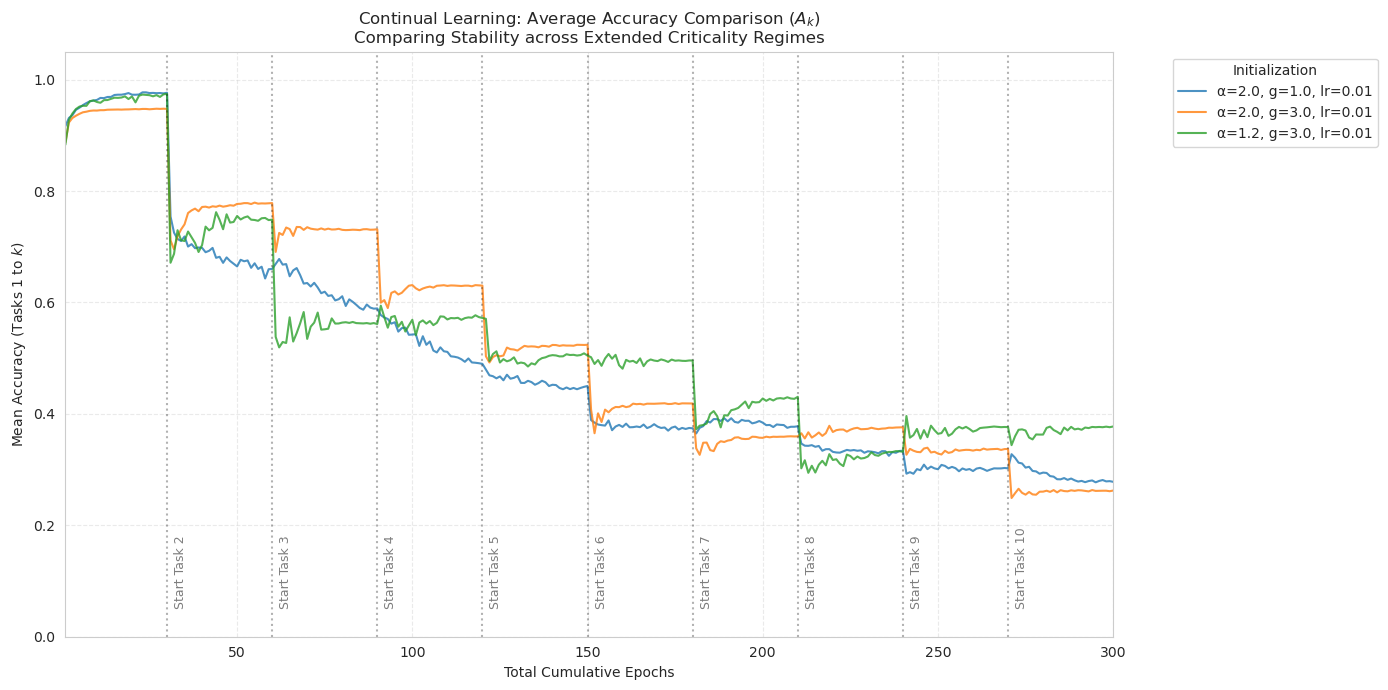

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
results_path = Path("./results_fc10_sgd")
task_success_threshold = 0.00  # Filter out "dead" seeds
num_tasks = 10

def plot_multiple_accuracies(param_pairs):
    """
    param_pairs: List of tuples [(alpha, g, lr), (alpha, g, lr), ...]
    """
    master_plot_data = []
    task_transition_epochs = None

    for alpha, g, lr in param_pairs:
        folder_name = f"alpha_{alpha}_g_{g}_lr_{lr}"
        folder_path = results_path / folder_name
        condition_label = f"α={alpha}, g={g}, lr={lr}"

        if not folder_path.exists():
            print(f"Skipping: {folder_path} (not found).")
            continue

        seed_count = 0
        for csv_file in folder_path.glob("results_log_seed_*.csv"):
            df = pd.read_csv(csv_file)

            # Trainability Filter: Ensure model successfully learned Task 1
            if df[df['task_id'] == 1]['task_1_acc'].max() < task_success_threshold:
                continue

            seed_count += 1

            # Calculate Mean Accuracy (Ak) for every cumulative epoch
            for idx, row in df.iterrows():
                current_task_id = int(row['task_id'])
                # Average only the tasks introduced so far
                task_cols = [f"task_{i}_acc" for i in range(1, current_task_id + 1)]
                mean_acc = row[task_cols].mean()

                master_plot_data.append({
                    "Total Epoch": idx + 1,
                    "Average Accuracy": mean_acc,
                    "Condition": condition_label,
                    "Seed": seed_count
                })

            # Capture transition points from the first successful seed
            if task_transition_epochs is None:
                task_transition_epochs = df.groupby('task_id').size().cumsum().tolist()

        print(f"Processed {seed_count} successful seeds for {condition_label}")

    if not master_plot_data:
        print("No data found to plot.")
        return

    # Convert to DataFrame for Seaborn
    plot_df = pd.DataFrame(master_plot_data)

    # --- Plotting ---
    plt.figure(figsize=(14, 7))
    sns.lineplot(
        data=plot_df,
        x="Total Epoch",
        y="Average Accuracy",
        hue="Condition",
        errorbar="sd",
        alpha=0.8
    )

    # Vertical markers for Task transitions
    if task_transition_epochs:
        # Don't draw line for the final epoch
        for t_idx, epoch_mark in enumerate(task_transition_epochs[:-1]):
            plt.axvline(x=epoch_mark, color='black', linestyle=':', alpha=0.3)
            plt.text(epoch_mark + 2, 0.05, f"Start Task {t_idx+2}",
                     fontsize=9, rotation=90, verticalalignment='bottom', alpha=0.6)

    plt.title("Continual Learning: Average Accuracy Comparison ($A_k$)\n"
              "Comparing Stability across Extended Criticality Regimes")
    plt.ylim(0, 1.05)
    plt.xlim(1, plot_df["Total Epoch"].max())
    plt.ylabel("Mean Accuracy (Tasks 1 to $k$)")
    plt.xlabel("Total Cumulative Epochs")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Initialization")
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# --- Execution Example ---
# Compare Gaussian Baseline vs various Heavy-Tailed setups[cite: 1]
comparison_list = [
    (2.0, 1.0, 0.01),  # Standard Gaussian Edge-of-Chaos[cite: 1]
    (2.0, 3.0, 0.01),  # Standard Gaussian Edge-of-Chaos[cite: 1]
    (1.2, 3.0, 0.01),  # Standard Gaussian Edge-of-Chaos[cite: 1]
]

plot_multiple_accuracies(comparison_list)

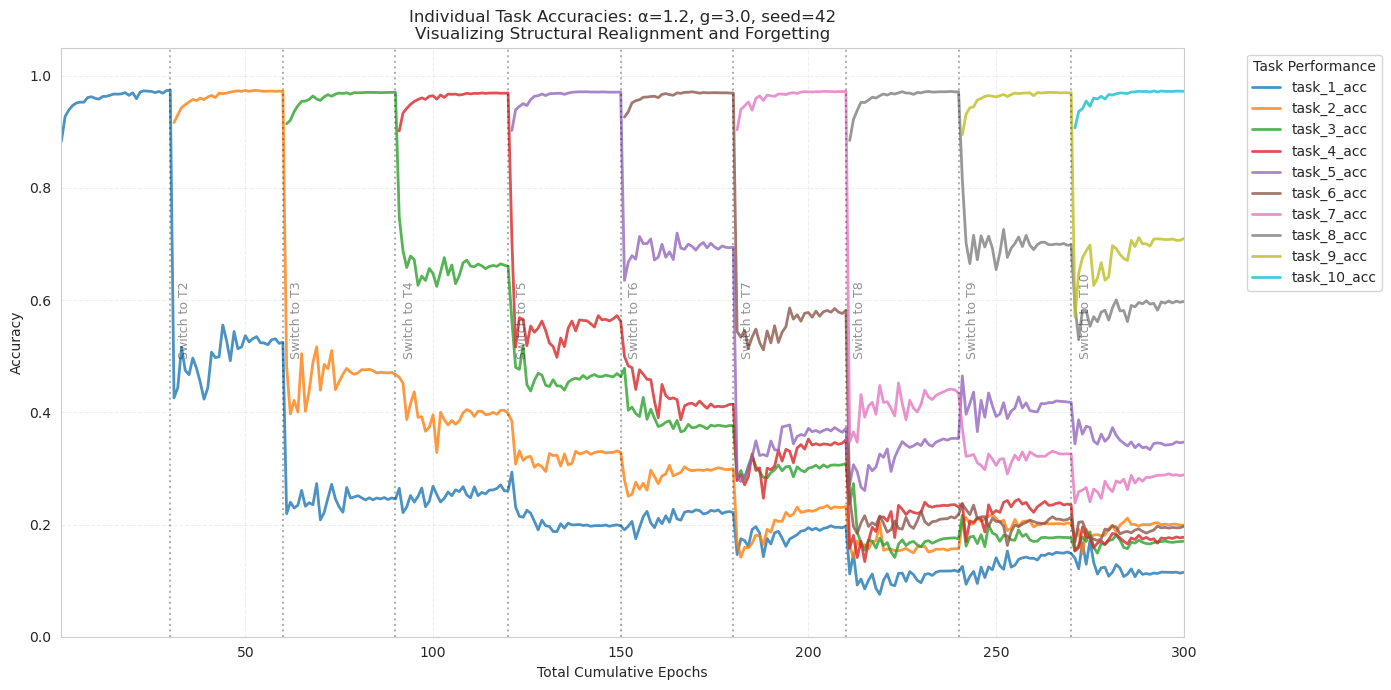

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
results_path = Path("./results_fc10_sgd")
num_tasks = 10

def plot_individual_task_curves(alpha, g, lr, seed=42):
    """
    Plots the individual task accuracy lines for a specific run.
    Helps identify the 'Warm Start' phenomenon and Catastrophic Forgetting.
    """
    folder_name = f"alpha_{alpha}_g_{g}_lr_{lr}"
    folder_path = results_path / folder_name
    csv_file = folder_path / f"results_log_seed_{seed}.csv"

    if not csv_file.exists():
        print(f"File not found: {csv_file}")
        return

    df = pd.read_csv(csv_file)

    # We need to melt the task columns into a long format for Seaborn
    # Columns are: [Total Epoch, task_1_acc, task_2_acc, ..., task_10_acc]
    task_cols = [f"task_{i}_acc" for i in range(1, num_tasks + 1)]

    # Track the cumulative epoch index (1 to 300 for 10 tasks x 30 epochs)
    df['Cumulative Epoch'] = range(1, len(df) + 1)

    # Melt data for plotting
    plot_df = df.melt(
        id_vars=['Cumulative Epoch'],
        value_vars=task_cols,
        var_name='Task',
        value_name='Accuracy'
    )

    # --- Plotting ---
    plt.figure(figsize=(14, 7))

    # Highlight the current task learning with a thicker line
    # Older tasks will appear as decaying curves[cite: 1, 2]
    sns.lineplot(
        data=plot_df,
        x="Cumulative Epoch",
        y="Accuracy",
        hue="Task",
        palette="tab10",
        linewidth=2,
        alpha=0.8
    )

    # Capture transition points for vertical lines
    task_transition_epochs = df.groupby('task_id').size().cumsum().tolist()

    for t_idx, epoch_mark in enumerate(task_transition_epochs[:-1]):
        plt.axvline(x=epoch_mark, color='black', linestyle=':', alpha=0.3)
        plt.text(epoch_mark + 2, 0.5, f"Switch to T{t_idx+2}",
                 fontsize=9, rotation=90, alpha=0.5)

    plt.title(f"Individual Task Accuracies: α={alpha}, g={g}, seed={seed}\n"
              f"Visualizing Structural Realignment and Forgetting")
    plt.ylim(0, 1.05)
    plt.xlim(1, len(df))
    plt.ylabel("Accuracy")
    plt.xlabel("Total Cumulative Epochs")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Task Performance")
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- Execution ---
# Visualize the Heavy-Tailed run to inspect Task 1 'Rich Learning' vs Task 2 'Warm Start'
plot_individual_task_curves(alpha=1.2, g=3.0, lr=0.01, seed=42)

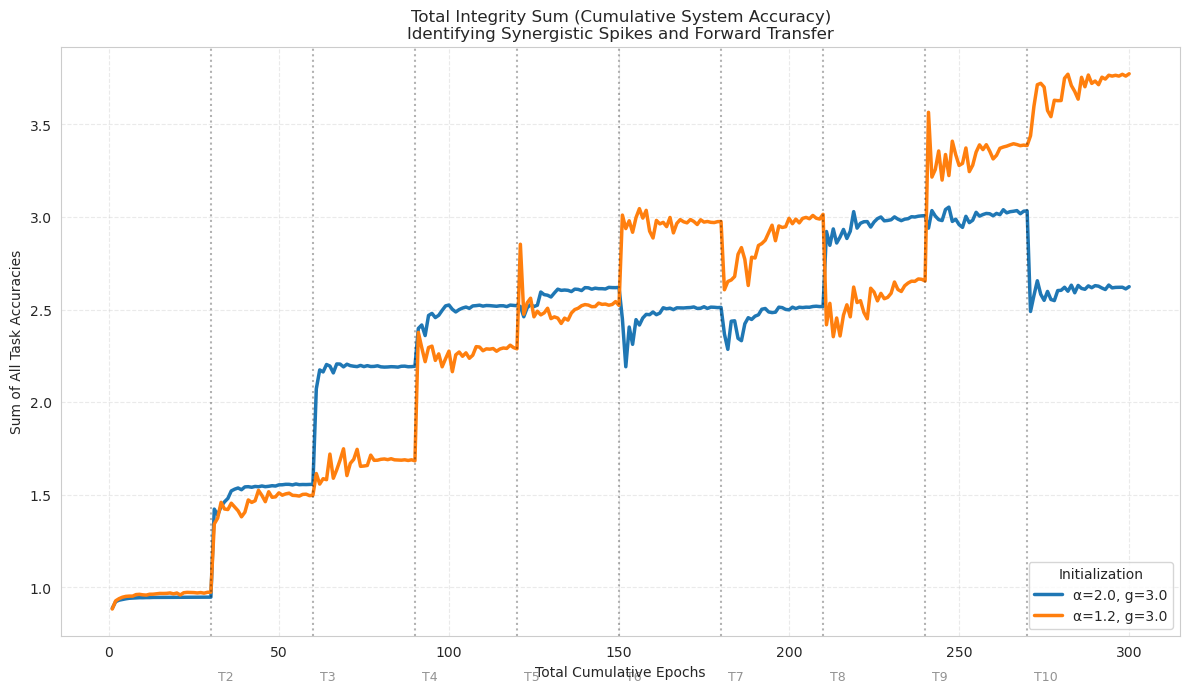

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
results_path = Path("./results_fc10_sgd")
num_tasks = 10

def plot_total_integrity_sum(param_pairs, seed=42):
    """
    Plots the sum of all task accuracies over time.
    Captures transient synergies (spikes) and integrated stability.
    """
    plt.figure(figsize=(12, 7))

    for alpha, g, lr in param_pairs:
        folder_name = f"alpha_{alpha}_g_{g}_lr_{lr}"
        csv_file = results_path / folder_name / f"results_log_seed_{seed}.csv"

        if not csv_file.exists():
            print(f"Skipping {folder_name}: File not found.")
            continue

        df = pd.read_csv(csv_file)
        df['Total Epoch'] = range(1, len(df) + 1)

        # Calculate the Total Integrity: Sum of all tasks (1-10) at every epoch
        task_cols = [f"task_{i}_acc" for i in range(1, num_tasks + 1)]
        df['Total_Integrity'] = df[task_cols].sum(axis=1)

        sns.lineplot(
            data=df,
            x='Total Epoch',
            y='Total_Integrity',
            label=f"α={alpha}, g={g}",
            linewidth=2.5
        )

    # Add vertical markers for task transitions
    task_transitions = df.groupby('task_id').size().cumsum().tolist()
    for t_idx, mark in enumerate(task_transitions[:-1]):
        plt.axvline(x=mark, color='black', linestyle=':', alpha=0.3)
        plt.text(mark + 2, 0.5, f"T{t_idx+2}", fontsize=9, alpha=0.5)

    plt.title("Total Integrity Sum (Cumulative System Accuracy)\n"
              "Identifying Synergistic Spikes and Forward Transfer")
    plt.ylabel("Sum of All Task Accuracies")
    plt.xlabel("Total Cumulative Epochs")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(title="Initialization")
    plt.tight_layout()
    plt.show()

# --- Execution ---
# Compare your HT discovery to the Gaussian baseline
comparison_list = [
    (2.0, 3.0, 0.01),  # Gaussian Baseline
    (1.2, 3.0, 0.01)   # Heavy-Tailed Discovery
]

plot_total_integrity_sum(comparison_list)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import sys
import os
import pandas as pd
from pathlib import Path

# Verbatim references to your project structure
sys.path.append(os.path.abspath(".."))
from src.architectures import GeneralMLP

# --- 1. CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROBE_EPOCHS = 30
BATCH_SIZE = 1024  # Large batch for fast GPU-preloaded probing
# Path to your physics snapshot
SNAPSHOT_PATH = Path("./results_fc10/alpha_2.0_g_3.0_lr_0.01/checkpoints/snapshot_T10_E29.pt")
OUTPUT_CSV = Path("../results/continual_learning") / "layerwise_probe_results.csv"

# Architecture params
DEPTH = 9
HIDDEN_SIZE = 784
INPUT_SIZE = 784
NUM_CLASSES = 10
BIAS = False

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

# --- 2. DATA PREPARATION (GPU PRELOADING) ---
def get_gpu_loader(train=True):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    dataset = datasets.MNIST(root='../data', train=train, download=True, transform=transform)
    all_data = torch.stack([img for img, _ in dataset]).to(DEVICE)
    all_targets = torch.tensor([label for _, label in dataset]).to(DEVICE)
    return DataLoader(TensorDataset(all_data, all_targets), batch_size=BATCH_SIZE, shuffle=train)

print("Preloading MNIST to GPU...")
train_loader = get_gpu_loader(train=True)
test_loader = get_gpu_loader(train=False)

# --- 3. LOADING BACKBONE ---
model = GeneralMLP(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES, DEPTH, bias=BIAS).to(DEVICE)

if SNAPSHOT_PATH.exists():
    checkpoint = torch.load(SNAPSHOT_PATH, map_location=DEVICE)
    if "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    else:
        # Fallback reconstruction
        new_state_dict = {}
        linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]
        for idx, layer in enumerate(linear_layers):
            layer_key = f"layer_{idx}" if idx < len(linear_layers) - 1 else "classifier"
            weight_data = checkpoint["layers"][layer_key]["weights"].to(torch.float32)
            for name, param in model.named_parameters():
                if param.shape == weight_data.shape and "weight" in name and name not in new_state_dict:
                    new_state_dict[name] = weight_data
                    break
        model.load_state_dict(new_state_dict, strict=False)
    print(f"Weights loaded from: {SNAPSHOT_PATH}")
else:
    raise FileNotFoundError(f"Missing snapshot at {SNAPSHOT_PATH}")

model.eval()
for param in model.parameters():
    param.requires_grad = False

# --- 4. LAYERWISE PROBING LOOP ---
all_layer_data = []

# Get the list of pre-activations to determine depth
with torch.no_grad():
    dummy = torch.zeros(1, INPUT_SIZE).to(DEVICE)
    pre_acts = model.get_pre_activations(dummy)

# Handle dictionary vs list return types from get_pre_activations
layer_keys = list(pre_acts.keys()) if isinstance(pre_acts, dict) else range(len(pre_acts))
num_layers = len(layer_keys)

for layer_idx in layer_keys:
    print(f"\n--- Probing Layer {layer_idx} ---")

    # Determine feature dimension
    with torch.no_grad():
        dummy = torch.zeros(1, INPUT_SIZE).to(DEVICE)
        feature_dim = model.get_pre_activations(dummy)[layer_idx].shape[1]

    probe = nn.Linear(feature_dim, NUM_CLASSES).to(DEVICE)
    # Using SGD as requested to observe the "raw" landscape physics
    optimizer = optim.SGD(probe.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(PROBE_EPOCHS):
        probe.train()
        running_loss = 0.0

        for data, target in train_loader:
            with torch.no_grad():
                feats = model.get_pre_activations(data)[layer_idx]

            optimizer.zero_grad()
            loss = criterion(probe(feats), target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Evaluation
        probe.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                feats = model.get_pre_activations(data)[layer_idx]
                correct += probe(feats).argmax(dim=1).eq(target).sum().item()

        epoch_acc = 100. * correct / 10000
        avg_loss = running_loss / len(train_loader)

        # Capture FULL info for analysis
        all_layer_data.append({
            "layer": layer_idx,
            "epoch": epoch + 1,
            "loss": avg_loss,
            "accuracy": epoch_acc
        })

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:<10.4f} | Acc: {epoch_acc:.2f}%")

# --- 5. SAVE FULL RESULTS ---
df = pd.DataFrame(all_layer_data)
df.to_csv(OUTPUT_CSV, index=False)
print(f"\nFull trajectory saved to: {OUTPUT_CSV}")

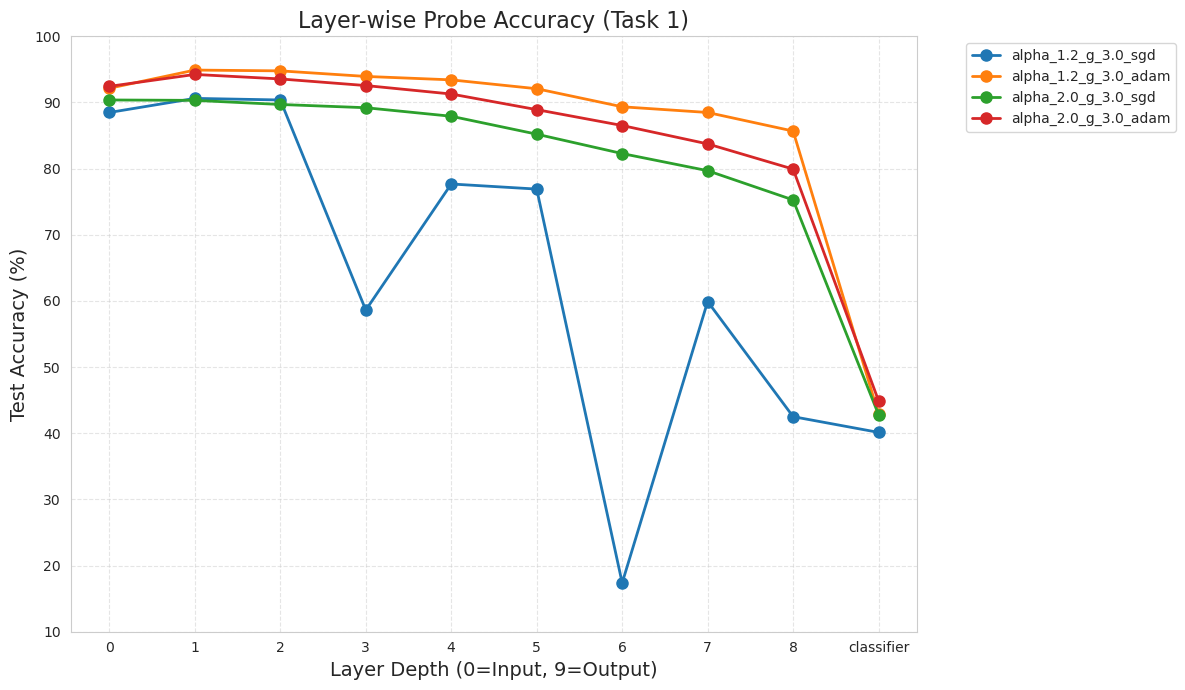

In [58]:
import pandas as pd
from pathlib import Path

# --- 1. SELECTION ---
# Add or remove filenames from this list to compare different runs
files_to_plot = [
    "layerwise_probe_results_alpha_1.2_g_3.0_sgd.csv",
    "layerwise_probe_results_alpha_1.2_g_3.0_adam.csv",
    "layerwise_probe_results_alpha_2.0_g_3.0_sgd.csv",
    "layerwise_probe_results_alpha_2.0_g_3.0_adam.csv"
]

base_path = Path("../results/continual_learning")

# --- 2. PLOTTING ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

for file_name in files_to_plot:
    path = base_path / file_name
    if not path.exists():
        print(f"Skipping {file_name}: File not found.")
        continue

    df = pd.read_csv(path)

    # We want to plot the FINAL accuracy achieved at each layer
    # after the probe has finished its epochs
    final_accs = df.groupby("layer")["accuracy"].max().reset_index()

    # Extract metadata from filename for cleaner labeling
    label = file_name.replace("layerwise_probe_results_", "").replace(".csv", "")

    plt.plot(final_accs["layer"], final_accs["accuracy"],
             marker='o', label=label, linewidth=2, markersize=8)

# --- 3. REFINING ---
plt.title("Layer-wise Probe Accuracy (Task 1)", fontsize=16)
plt.xlabel("Layer Depth (0=Input, 9=Output)", fontsize=14)
plt.ylabel("Test Accuracy (%)", fontsize=14)
plt.ylim(10, 100)
plt.xticks(range(10))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(base_path / "layerwise_probe_comparison.pdf", bbox_inches='tight')
plt.show()

<>:76: SyntaxWarning: invalid escape sequence '\k'
<>:77: SyntaxWarning: invalid escape sequence '\s'
<>:76: SyntaxWarning: invalid escape sequence '\k'
<>:77: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_56281/4083236628.py:76: SyntaxWarning: invalid escape sequence '\k'
  axes[2].set_title("Condition Number ($\kappa$)\n(Higher = More Rugged/Curved)")
/tmp/ipykernel_56281/4083236628.py:77: SyntaxWarning: invalid escape sequence '\s'
  axes[2].set_ylabel("$\sigma_{max} / \sigma_{min}$ (Log Scale)")


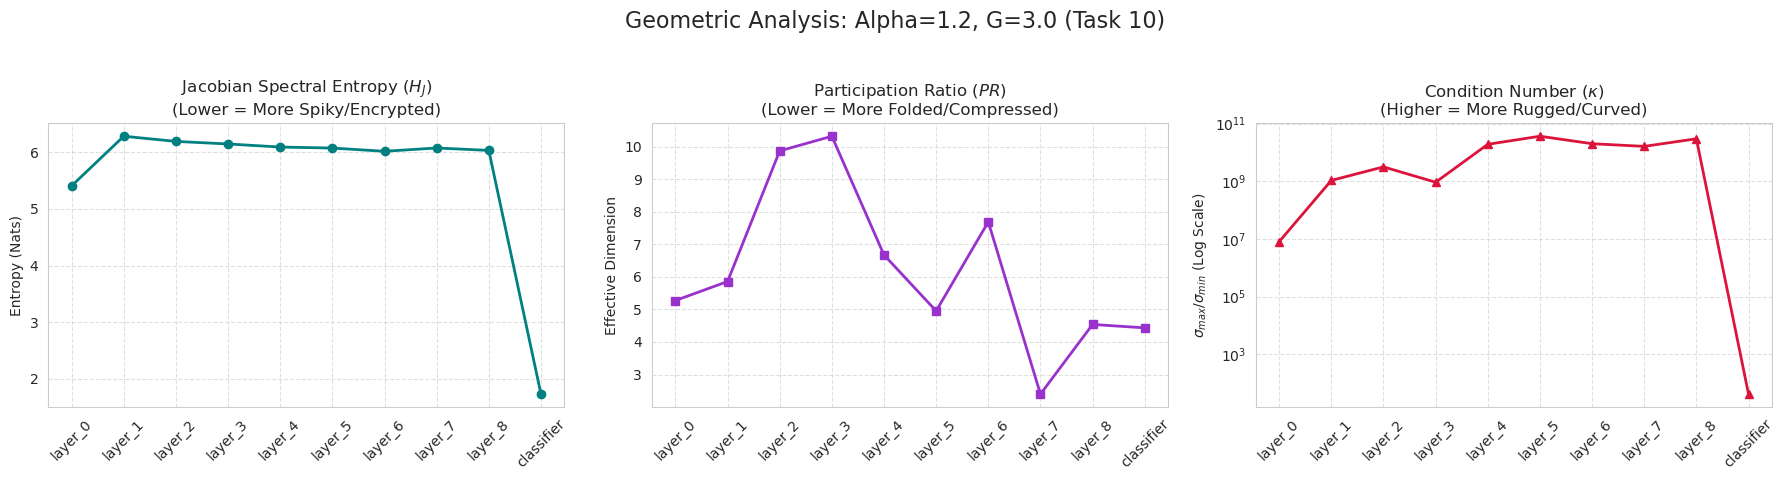

In [57]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1. CONFIGURATION ---
# Point this to the snapshot you want to analyze
SNAPSHOT_FILE = Path("./results_fc10/alpha_1.2_g_3.0_lr_0.01/checkpoints/snapshot_T10_E29.pt")

def analyze_geometry(snapshot_path):
    checkpoint = torch.load(snapshot_path, map_location='cpu')
    physics_data = checkpoint['physics']
    metadata = checkpoint['metadata']

    layers = []
    entropy_list = []
    pr_list = []
    cond_list = []

    # Iterate through layers in order
    # Layer keys are usually 'layer_0', 'layer_1' ... 'classifier'
    sorted_keys = sorted(physics_data.keys(), key=lambda x: int(x.split('_')[1]) if 'layer' in x else 99)

    for key in sorted_keys:
        # Load physics tensors
        h = physics_data[key]['pre_activations']  # [Batch, Hidden]
        J = physics_data[key]['jacobian']         # [Out, In]

        # --- A. Jacobian Spectral Entropy (H_j) ---
        # Get singular values of the Jacobian
        s = torch.linalg.svdvals(J)
        s = s[s > 1e-10]  # Filter numerical noise
        p = s / s.sum()
        entropy = -torch.sum(p * torch.log(p)).item()

        # --- B. Participation Ratio (PR) ---
        # Measure dimensionality of the pre-activation manifold
        # Covariance matrix of h
        h_centered = h - h.mean(dim=0)
        cov = (h_centered.T @ h_centered) / (h.shape[0] - 1)
        eigvals = torch.linalg.eigvalsh(cov)
        eigvals = eigvals[eigvals > 0] # Filter noise
        pr = (eigvals.sum()**2 / (eigvals**2).sum()).item()

        # --- C. Condition Number (Kappa) ---
        # Measure landscape ruggedness/ill-conditioning
        cond = (s.max() / s.min()).item()

        layers.append(key)
        entropy_list.append(entropy)
        pr_list.append(pr)
        cond_list.append(cond)

    return layers, entropy_list, pr_list, cond_list, metadata

# --- 2. EXECUTION & PLOTTING ---
layers, entropy, pr, cond, meta = analyze_geometry(SNAPSHOT_FILE)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Geometric Analysis: Alpha={meta['alpha']}, G={meta['g']} (Task {meta['task']})", fontsize=16)

# Plot Spectral Entropy
axes[0].plot(layers, entropy, marker='o', color='teal', linewidth=2)
axes[0].set_title("Jacobian Spectral Entropy ($H_J$)\n(Lower = More Spiky/Encrypted)")
axes[0].set_ylabel("Entropy (Nats)")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot Participation Ratio
axes[1].plot(layers, pr, marker='s', color='darkorchid', linewidth=2)
axes[1].set_title("Participation Ratio ($PR$)\n(Lower = More Folded/Compressed)")
axes[1].set_ylabel("Effective Dimension")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot Condition Number (Log Scale)
axes[2].semilogy(layers, cond, marker='^', color='crimson', linewidth=2)
axes[2].set_title("Condition Number ($\kappa$)\n(Higher = More Rugged/Curved)")
axes[2].set_ylabel("$\sigma_{max} / \sigma_{min}$ (Log Scale)")
axes[2].grid(True, linestyle='--', alpha=0.6)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(Path("../results/continual_learning") / f"geometry_analysis_alpha_{meta['alpha']}_g_{meta['g']}_task.pdf", bbox_inches='tight')
plt.show()